In [1]:
# TO DO:
# update with daily data
# debug rolling forecast (only one forecast right now)

In [50]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [51]:
## Forecasting 

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    
    if method == 'last_season':
        pred_last_season = []
            
        for i in range(train_len, total_len, window):
            last_season = df[0][i-window:i]
            pred_last_season.extend(last_season)
            
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df_train[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [52]:
# Define SARIMA model
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [2]:
# read in the merged station datasets
dfs = {}
for index in range(0, 6) :
  df = pd.read_csv('merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df


In [3]:
#drop these two features because they mess up station 4. Temporary solution
for key in dfs.keys():
  dfs[key].drop(['SWC_50'], axis = 1, inplace = True)
  dfs[key].drop(['T_50'], axis = 1, inplace = True)


In [4]:
#drop flag feature and null values

for station, df in dfs.items() :
  # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
  df = df.drop('Flag', axis = 1)
  # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
  df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
  df_new.dropna(inplace=True)
  dfs[station] = df_new

In [5]:
#Vectorize wind
for station, df in dfs.items() :
  # convert wind velocity and wind direction to a wind vector
  wv = df.pop('Windspeed')

  # Convert to radians.
  wd_rad = df.pop('Winddirection')*np.pi / 180

  # Calculate the wind x and y components.
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

In [6]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)

  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

  dfs[station] = df

In [7]:
# create one standard metric for PPT
for key in dfs.keys():
  dfs[key]['PPT'] = (dfs[key].pop('Ppt_soil') + dfs[key].pop('Ppt_met'))/2

In [8]:
#Normalize all the data

for key in dfs.keys():
  dfs[key] = (dfs[key] - dfs[key].min())/(dfs[key].max()-dfs[key].min())

In [9]:
#add geographical position data

position_dict = {"Station1": [30.3989,-98.6105],
                 "Station2": [30.4193,-98.8046],
                 "Station3": [30.4421,-98.8427],
                 "Station4": [30.4600, -98.9407],
                 "Station5": [30.2454,-98.7059],
                 "Station6": [30.2758,-98.7242]
                 }

for key in dfs.keys():
  dfs[key]["Latitude"] = position_dict[key][0]
  dfs[key]["Longitude"] = position_dict[key][1]

In [10]:
#only use data shared all together: indexes that are none null for each station

index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)

index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)


print(len(index_int))


45185


# Create Multi-Index DF for all Station Data

In [11]:
feats = dfs['Station1'].columns.tolist()

stations = list(dfs.keys())

In [12]:
index = index_int

cols = pd.MultiIndex.from_product([stations,feats], names = ['Station', 'Feature'])

In [13]:
for station, df in dfs.items():
  cols_new = []
  for col in df.columns.tolist():
    cols_new.append(f"{station} {col}")
  df.columns = cols_new

In [14]:
lis = [dfs[key].loc[index] for key in dfs.keys()]

data = pd.concat(lis, axis = 1)

data.head()

,Station1 SWC_5,Station1 SWC_10,Station1 SWC_20,Station1 T_5,Station1 T_10,Station1 T_20,Station1 Tair,Station1 RH,Station1 Srad,Station1 Wx,...,Station6 Srad,Station6 Wx,Station6 Wy,Station6 Day sin,Station6 Day cos,Station6 Year sin,Station6 Year cos,Station6 PPT,Station6 Latitude,Station6 Longitude
2016-02-20 13:00:00,0.139623,0.219626,0.208054,0.409553,0.414440,0.417014,0.912188,0.870606,0.350557,0.318500,...,0.326054,0.327554,0.519249,0.370590,0.017037,0.881128,0.823638,0.0,30.2758,-98.7242
2016-02-20 15:00:00,0.143396,0.224299,0.208054,0.451220,0.447961,0.434964,0.917929,0.812634,0.367328,0.353486,...,0.380189,0.385141,0.561426,0.146447,0.146447,0.881591,0.823091,0.0,30.2758,-98.7242
2016-02-20 16:00:00,0.147170,0.228972,0.214765,0.463618,0.462260,0.445890,0.924424,0.799389,0.392486,0.368937,...,0.443144,0.382056,0.563651,0.066987,0.250000,0.881823,0.822818,0.0,30.2758,-98.7242
2016-02-20 17:00:00,0.143396,0.228972,0.208054,0.468089,0.472808,0.456296,0.927341,0.797453,0.213525,0.369872,...,0.196865,0.413326,0.599024,0.017037,0.370590,0.882054,0.822544,0.0,30.2758,-98.7242
2016-02-20 18:00:00,0.143396,0.228972,0.214765,0.457317,0.476090,0.465140,0.924894,0.823484,0.078887,0.390298,...,0.076036,0.429337,0.603361,0.000000,0.500000,0.882285,0.822270,0.0,30.2758,-98.7242


In [15]:
df = pd.DataFrame(data = data.values, index = index, columns = cols)

# Data Split

In [16]:
#create Df of our target Values

target_station = 'Station6'

target_names = ['SWC_5']

target_df = df[target_station][target_names]

target_df.shape

(45185, 1)

In [17]:
#Create DF of all our data not the target
non_targets = list(dfs.keys())

non_targets.remove('Station6')

train_df = df[non_targets]

train_df.shape

train=[]
test=[]

for station, feature in df:
    
    if feature == "SWC_5" and station != 'Station6':
        train.extend(df[station].SWC_5)
    elif feature == "SWC_5":
        test.extend(df[station].SWC_5)


In [18]:
df_train = pd.DataFrame(train[::24*30])
df_test = pd.DataFrame(test[::24*30])
df_total = pd.concat([df_train, df_test], ignore_index=True)

train_len = len(df_train)
test_len = len(df_test)

total_len = train_len + test_len

In [19]:
df_test

,0
0,0.168317
1,0.222772
2,0.534653
3,0.381188
4,0.113861
...,...
58,0.485149
59,0.524752
60,0.292079
61,0.232673


In [22]:
# Define range of parameter's to check
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12


In [23]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(df_train, None, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

[(0, 0, 0, 0), 333.79613006896517]
[(0, 0, 0, 1), 177.30239666626824]
[(0, 0, 1, 0), 11.254336281805973]
[(0, 0, 1, 1), -67.7019357098123]
[(0, 1, 0, 0), 150.2734743703367]
[(0, 1, 0, 1), 70.96673860925004]
[(0, 1, 1, 0), -19.911921118684926]
[(0, 1, 1, 1), -101.09713677143299]
[(1, 0, 0, 0), -53.21791203397929]
[(1, 0, 0, 1), -59.89885372113767]
[(1, 0, 1, 0), -62.63508911300913]
[(1, 0, 1, 1), -112.80741268437698]
[(1, 1, 0, 0), -87.94776274155493]
[(1, 1, 0, 1), -102.80771459605764]
[(1, 1, 1, 0), -105.26248487693955]
[(1, 1, 1, 1), -112.95427404414309]


,"(p,q,P,Q)",AIC
0,"(1, 1, 1, 1)",-112.954274
1,"(1, 0, 1, 1)",-112.807413
2,"(1, 1, 1, 0)",-105.262485
3,"(1, 1, 0, 1)",-102.807715
4,"(0, 1, 1, 1)",-101.097137
5,"(1, 1, 0, 0)",-87.947763
6,"(0, 0, 1, 1)",-67.701936
7,"(1, 0, 1, 0)",-62.635089
8,"(1, 0, 0, 1)",-59.898854
9,"(1, 0, 0, 0)",-53.217912


In [24]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(df_train, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  0   No. Observations:                  314
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                  63.554
Date:                            Wed, 30 Aug 2023   AIC                           -117.108
Time:                                    17:42:06   BIC                            -98.589
Sample:                                         0   HQIC                          -109.697
                                            - 314                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4939      0.126      3.905      0.000       0.246       0.742
ma.L1         -0.1510      0.144   

In [26]:
pred_df = df_test.copy()

In [48]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len)

pred_df['last_season'] = rolling_forecast(df_train, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
pred_df.last_season

0     0.793785
1     0.557756
2     0.666667
3     0.597360
4     0.465347
        ...   
58    0.551155
59    0.630363
60    0.376238
61    0.254125
62    0.303630
Name: last_season, Length: 63, dtype: float64

In [49]:
# Define SARIMA Prediction Dataframe
pred_df['SARIMA'] = rolling_forecast(df_total, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df.SARIMA

0     0.220938
1     0.169369
2     0.167979
3     0.322211
4     0.263655
        ...   
58    0.281136
59    0.290820
60    0.209616
61    0.158650
62    0.154584
Name: SARIMA, Length: 63, dtype: float64

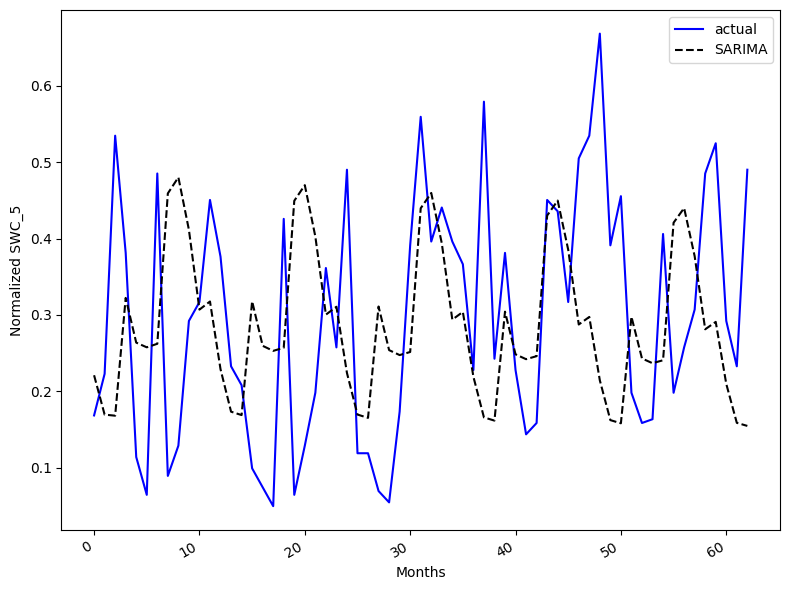

In [39]:
# visualize predictions
fig, ax = plt.subplots()

ax.plot(df_test, 'b-', label='actual')
# ax.plot(pred_df.last_season, 'r:', label='naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Months')
ax.set_ylabel('Normalized SWC_5')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

In [43]:
# Calculate MSE 
mse=mean_squared_error(df_test, pred_df.SARIMA)

# Calculate MAE
mae = mean_absolute_error(df_test, pred_df.SARIMA)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAPE
mape = np.mean(np.abs((df_test - pred_df.SARIMA) / df_test)) * 100

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

MSE: 0.0363
MAE: 0.1542
RMSE: 0.1905
MAPE: 64.4387%
